# Gaussian Naïve Bayes (GNB)

In [1]:
import sys; sys.path.insert(0, "..")

from utils.dependencies import *
from utils import (
    load_and_filter, impute, split_and_balance, FEATURES,
    get_class_meta,
    run_grid_search,
    print_classification_report, compute_f1_scores, run_stratified_cv, print_error_patterns,
    plot_f1_bar, plot_confusion_matrices, plot_posterior_violins,
)


## Model-Specific Data Processing

In [2]:
df = load_and_filter()
df = impute(df)

LOG_COLS = ["pl_bmasse", "pl_orbper", "pl_orbsmax", "sy_dist"]
for col in LOG_COLS:
    df[col] = np.log1p(df[col].clip(lower=0))

GNB_FEATURES = [f for f in FEATURES if f not in ("P_GRAVITY", "P_DENSITY", "P_ESCAPE")]

X_train_bal, y_train_bal, X_test_scaled, y_test, class_weight_dict, scaler = split_and_balance(
    df, features=GNB_FEATURES
)

class_names, classes, colors = get_class_meta()

Loaded: (5569, 18)
Nulls before imputation:
pl_orbper       260
pl_orbsmax     2237
pl_orbeccen    3315
pl_bmasse      2986
pl_rade        1373
pl_eqt         2402
st_teff         290
st_rad          321
st_mass         206
st_lum          675
st_met          424
st_logg         351
st_age         1246
P_GRAVITY         7
P_DENSITY         7
P_ESCAPE          7
sy_dist         118
dtype: int64

[Tier 2a] pl_orbeccen: filled 3315 with 0.0
[Tier 2b] pl_orbsmax: filled 2203 via Kepler's 3rd law
[Tier 2c] pl_orbper: filled 242 via Kepler's 3rd law (inverse)
[Tier 2d] st_lum: filled 362 via Stefan-Boltzmann law
[Tier 2e] pl_bmasse: filled 2972 via mass-radius relation
[Tier 2f] pl_rade: filled 1359 via inverse mass-radius relation
[Tier 2g] pl_eqt: filled 2073 via equilibrium temp formula
[Tier 2h-j] P_GRAVITY/DENSITY/ESCAPE: filled 0 via physics formulas

Nulls after Tier 2:
pl_orbper        18
pl_orbsmax       34
pl_orbeccen       0
pl_bmasse        14
pl_rade          14
pl_eqt          

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[Tier 4] RF Iterative Imputer on planetary features: 430 → 0 nulls
[Tier 5a] st_met: filled 424 via grouped median by spectral type
[Tier 5b] st_age: filled 1246 via RF regression + median fallback
[Tier 6] KNN imputer: 118 → 0 nulls

Train shape: (4455, 14)
Test shape:  (1114, 14)

Train distribution (BEFORE balancing):
P_HABITABLE
0.0    4399
1.0      23
2.0      33
Name: count, dtype: int64

Train distribution (AFTER balancing):
P_HABITABLE
0.0    300
1.0    200
2.0    199
Name: count, dtype: int64
Balanced train shape: (699, 14)
Class weights: {np.int64(0): np.float64(0.7766666666666666), np.int64(1): np.float64(1.165), np.int64(2): np.float64(1.170854271356784)}

Outputs ready for modeling:
  X_train_bal       → (699, 14) (balanced, scaled)
  y_train_bal       → 699 samples
  X_test_scaled     → (1114, 14) (held-out, scaled)
  y_test            → 1114 samples (original distribution)
  class_weight_dict → for class_weight param in classifiers


## Training

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# GAUSSIAN NAÏVE BAYES (GNB) — Baseline Classifier
# ══════════════════════════════════════════════════════════════════════════════
# GNB assumes features are independent and normally distributed per class.
# It has no class_weight parameter, so it relies entirely on the balanced
# training data from SMOTE. Expected to be the weakest model — sets the floor.

# ── Step 1: Tune var_smoothing ──
param_grid = {"var_smoothing": np.logspace(-12, -1, 25)}

grid_gnb = run_grid_search(GaussianNB(), param_grid, X_train_bal, y_train_bal)
gnb = grid_gnb.best_estimator_

y_pred_gnb = gnb.predict(X_test_scaled)
y_prob_gnb = gnb.predict_proba(X_test_scaled)

class_names, classes, colors = get_class_meta()

print("GNB training complete.")
print(f"Best var_smoothing: {grid_gnb.best_params_['var_smoothing']:.2e}")
print(f"Best CV F1 Macro:   {grid_gnb.best_score_:.4f}")

GNB training complete.
Best var_smoothing: 7.50e-06
Best CV F1 Macro:   0.8894


## Modeling

### DIAGNOSTIC PLOT 1: Class-Conditional Gaussian Distributions (Top 6 Features)

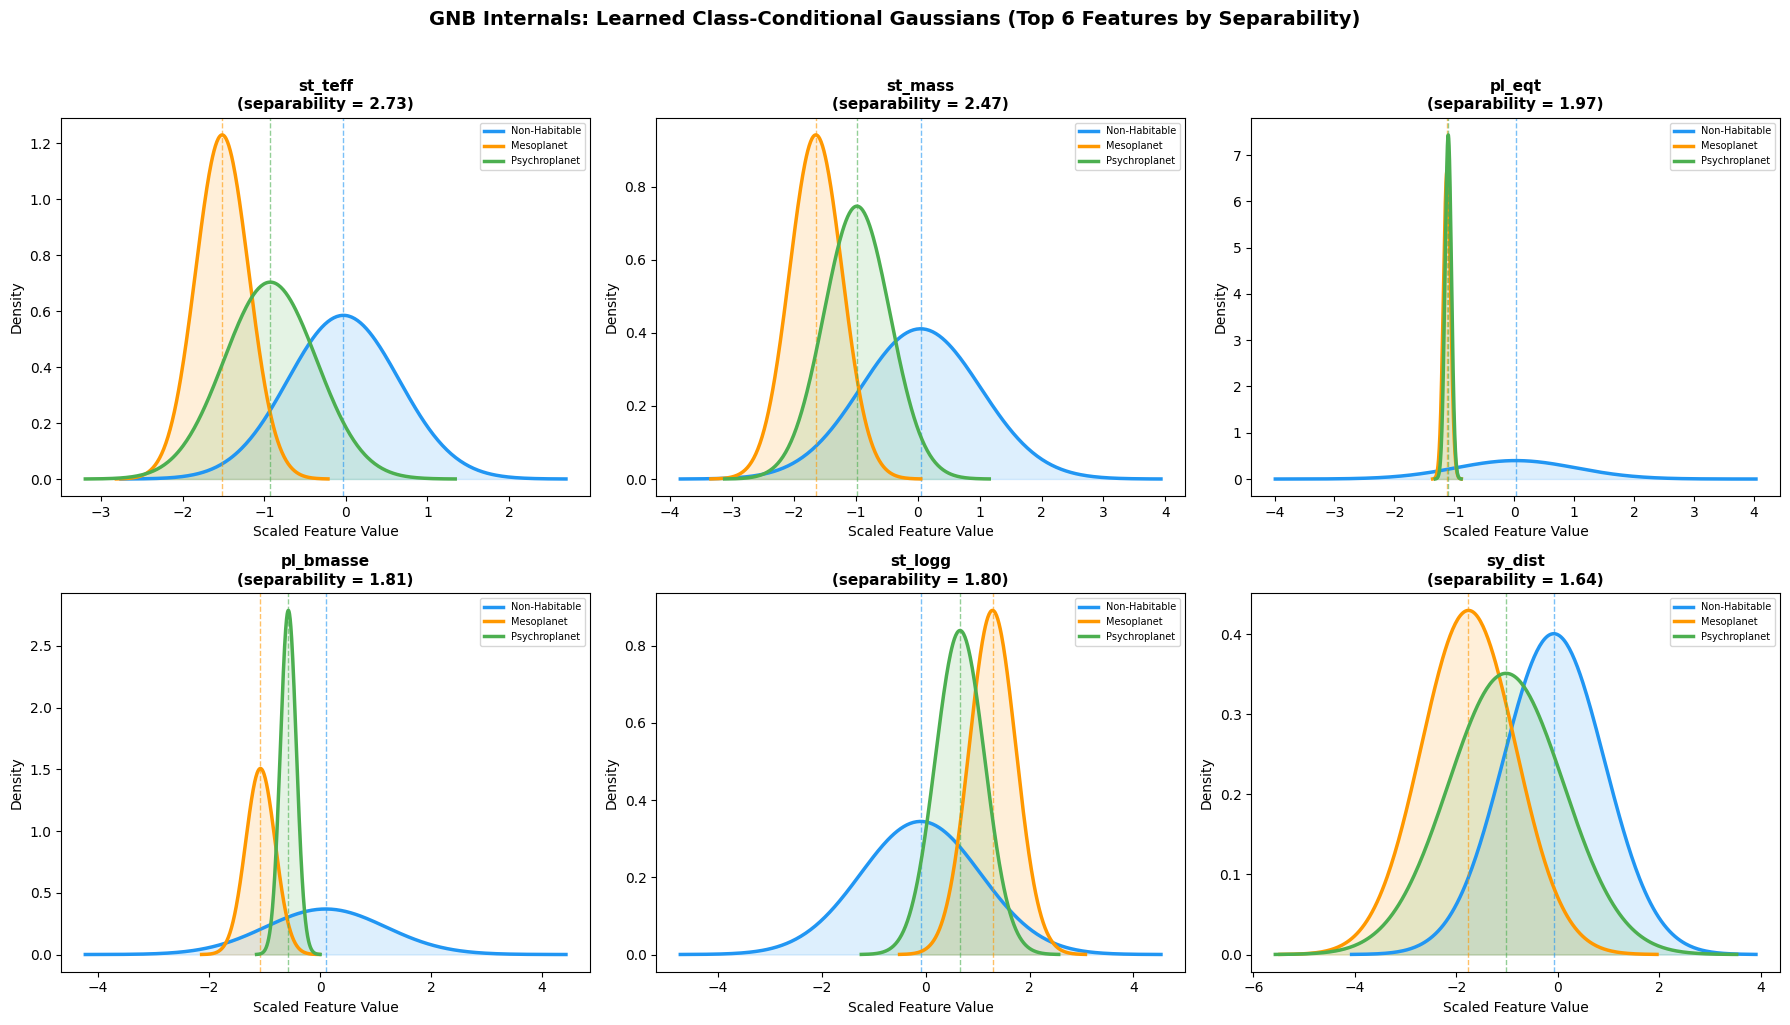

↑ Each curve is the Gaussian that GNB learned for that (feature, class) pair.


In [4]:
separability = []
for j, feat in enumerate(GNB_FEATURES):
    means = gnb.theta_[:, j]
    varis = gnb.var_[:, j]
    spread = means.max() - means.min()
    pooled_std = np.sqrt(np.mean(varis))
    separability.append((spread / (pooled_std + 1e-12), feat, j))

separability.sort(reverse=True)
top_features = separability[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax_idx, (sep_score, feat_name, feat_idx) in enumerate(top_features):
    ax = axes[ax_idx]

    for c in range(3):
        mu = gnb.theta_[c, feat_idx]
        sigma = np.sqrt(gnb.var_[c, feat_idx])

        x_range = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 300)
        pdf = norm.pdf(x_range, mu, sigma)

        ax.plot(x_range, pdf, color=colors[c], lw=2.5, label=class_names[c])
        ax.fill_between(x_range, pdf, alpha=0.15, color=colors[c])
        ax.axvline(mu, color=colors[c], ls="--", lw=1, alpha=0.6)

    ax.set_title(f"{feat_name}\n(separability = {sep_score:.2f})", fontsize=11, fontweight="bold")
    ax.set_xlabel("Scaled Feature Value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7, loc="upper right")

fig.suptitle("GNB Internals: Learned Class-Conditional Gaussians (Top 6 Features by Separability)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_plot("gnb_class_conditionals")
plt.show()

print("↑ Each curve is the Gaussian that GNB learned for that (feature, class) pair.")

### DIAGNOSTIC PLOT 2: Predicted Posterior Probability Distributions by True Class

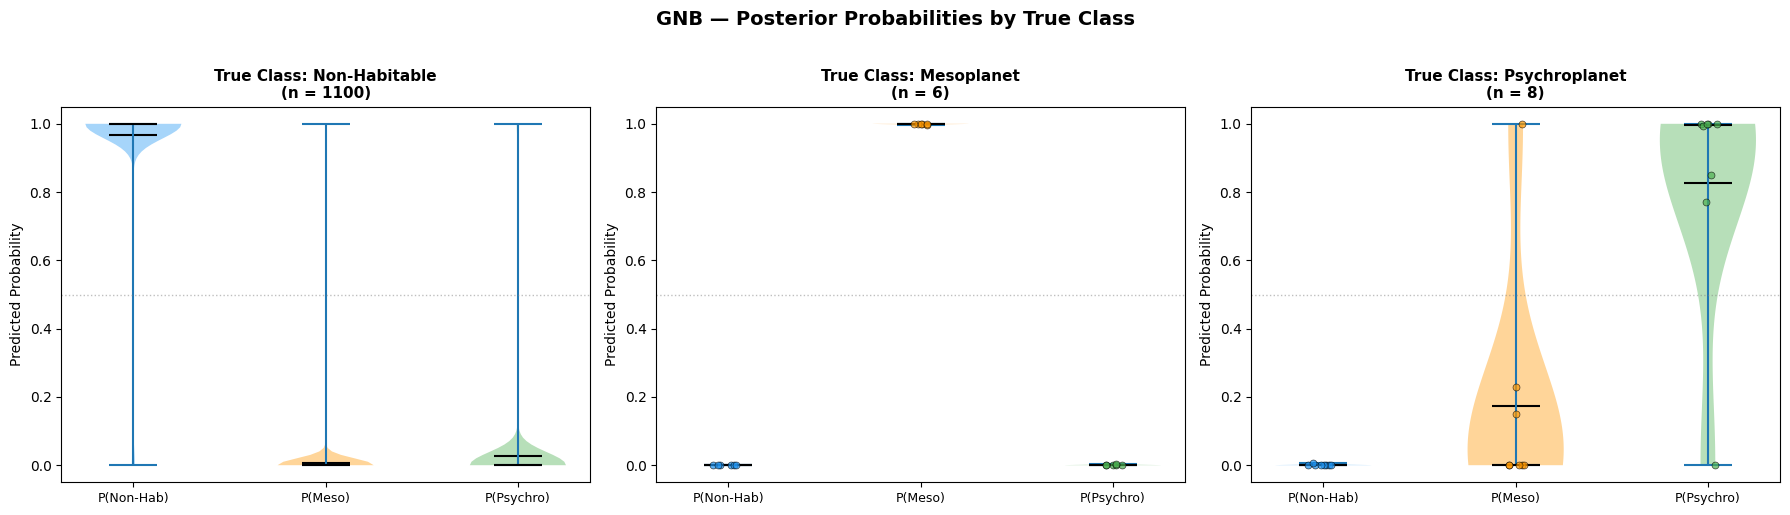

↑ For each true class, the violin shows the distribution of predicted probabilities.
  Ideal: for True Non-Habitable, P(Non-Hab) should be high and P(Meso)/P(Psychro) near 0.


In [5]:
plot_posterior_violins(y_test, y_prob_gnb, "GNB")

print("↑ For each true class, the violin shows the distribution of predicted probabilities.")
print("  Ideal: for True Non-Habitable, P(Non-Hab) should be high and P(Meso)/P(Psychro) near 0.")

## Metrics
### Classification Report + F1 Scores

Gaussian Naïve Bayes — Classification Report
               precision    recall  f1-score   support

Non-Habitable     1.0000    0.9682    0.9838      1100
   Mesoplanet     0.3750    1.0000    0.5455         6
Psychroplanet     0.2121    0.8750    0.3415         8

     accuracy                         0.9677      1114
    macro avg     0.5290    0.9477    0.6236      1114
 weighted avg     0.9910    0.9677    0.9769      1114

F1 Macro:    0.6236
F1 Weighted: 0.9769

5-Fold CV F1 Macro: 0.8852 ± 0.0318
F1 Macro:    0.6236
F1 Weighted: 0.9769


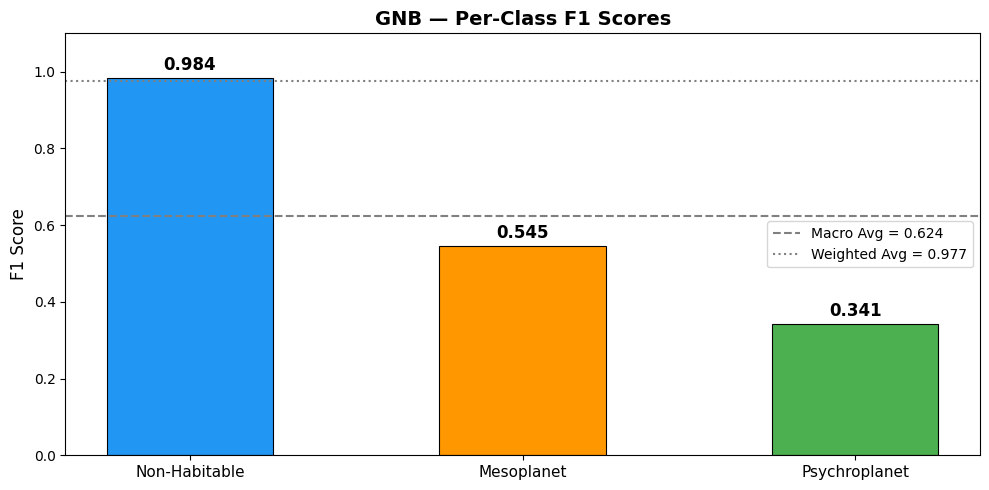

In [6]:
print_classification_report(y_test, y_pred_gnb, "Gaussian Naïve Bayes")

f1_macro_gnb, f1_weighted_gnb, _ = compute_f1_scores(y_test, y_pred_gnb)

cv_scores_gnb = run_stratified_cv(gnb, X_train_bal, y_train_bal)

plot_f1_bar(y_test, y_pred_gnb, "GNB")

### Confusion Matrices (Counts + Normalized)

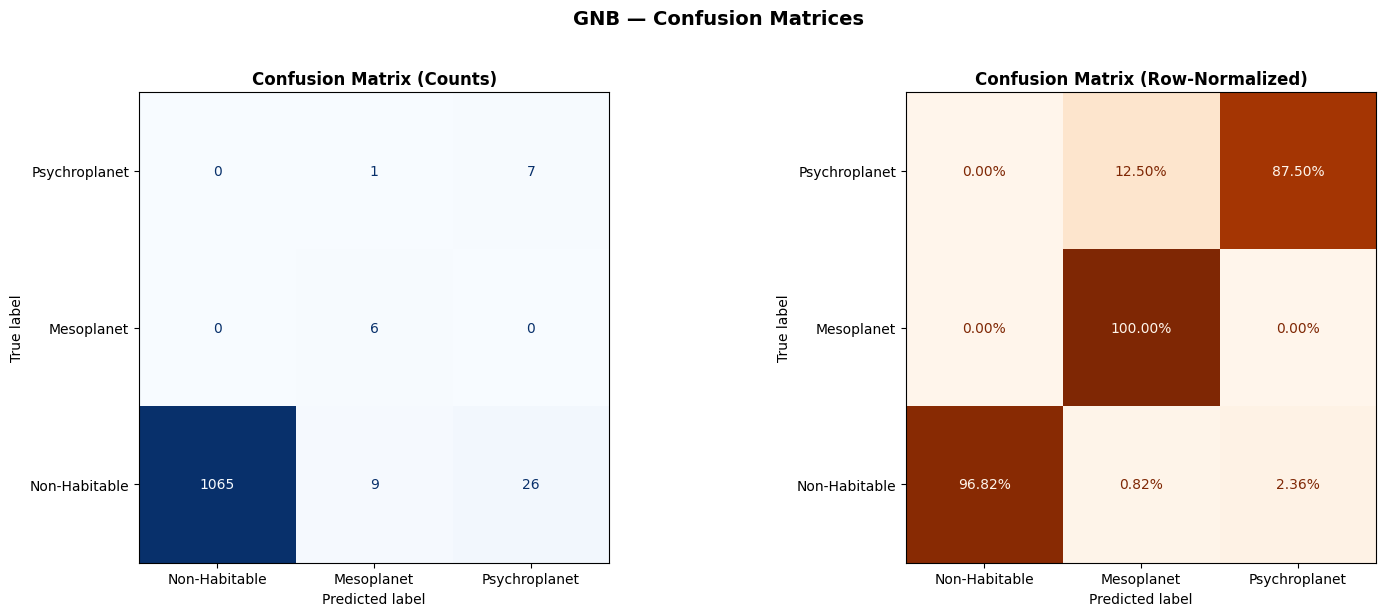

Key error patterns:
  Non-Habitable → predicted Mesoplanet: 9 (0.8% of true Non-Habitable)
  Non-Habitable → predicted Psychroplanet: 26 (2.4% of true Non-Habitable)
  Psychroplanet → predicted Mesoplanet: 1 (12.5% of true Psychroplanet)


In [7]:
plot_confusion_matrices(y_test, y_pred_gnb, "GNB")
print_error_patterns(y_test, y_pred_gnb)

## Interpretation
